In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
x=np.linspace(-5.0,5.0,100)
y=np.sqrt(10**2-x**2)
y=np.hstack([y,-y])
x=np.hstack([x,-x])

In [50]:
x1=np.linspace(-5.0,5.0,100)
y1=np.sqrt(5**2-x1**2)
y1=np.hstack([y1,-y1])
x1=np.hstack([x1,-x1])

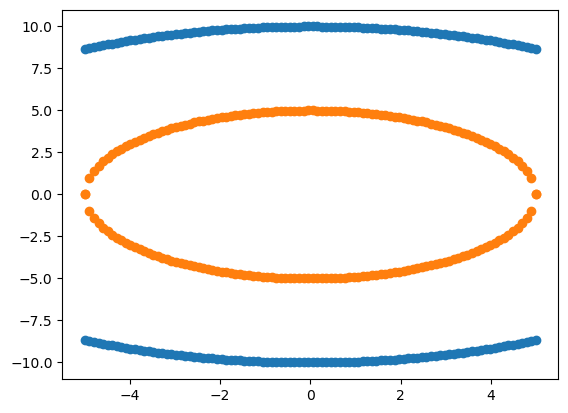

In [51]:
plt.scatter(x,y)
plt.scatter(x1,y1)

In [52]:
df1=pd.DataFrame(np.vstack([y,x]).T,columns=['X1','X2'])
df1['Y']=0
df2=pd.DataFrame(np.vstack([y1,x1]).T,columns=['X1','X2'])
df2['Y']=1
df=pd.concat([df1,df2])
df.head(5)

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [53]:
df.shape

(400, 3)

In [54]:
df.tail()

,X1,X2,Y
195,-1.969049,-4.59596,1
196,-1.714198,-4.69697,1
197,-1.406908,-4.79798,1
198,-0.999949,-4.89899,1
199,-0.000000,-5.00000,1


In [60]:
X3=df.iloc[:,:-1]
y3=df.iloc[:,-1]

In [61]:
y3

0      0
1      0
2      0
3      0
4      0
      ..
195    1
196    1
197    1
198    1
199    1
Name: Y, Length: 400, dtype: int64

In [62]:
from sklearn.model_selection import train_test_split
X3_train,X3_test,y3_train,y3_test=train_test_split(X3,y3,test_size=0.25,random_state=42)

In [63]:
## polynomial kernel
df['X1_square']=df['X1']**2
df['X2_Square']=df['X2']**2
df['X1*X2']=(df['X1']*df['X2'])
df.head()

,X1,X2,Y,X1_square,X2_Square,X1*X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [64]:
x=df[['X1','X2','X1_square','X2_Square','X1*X2']]
y=df['Y']

In [65]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)

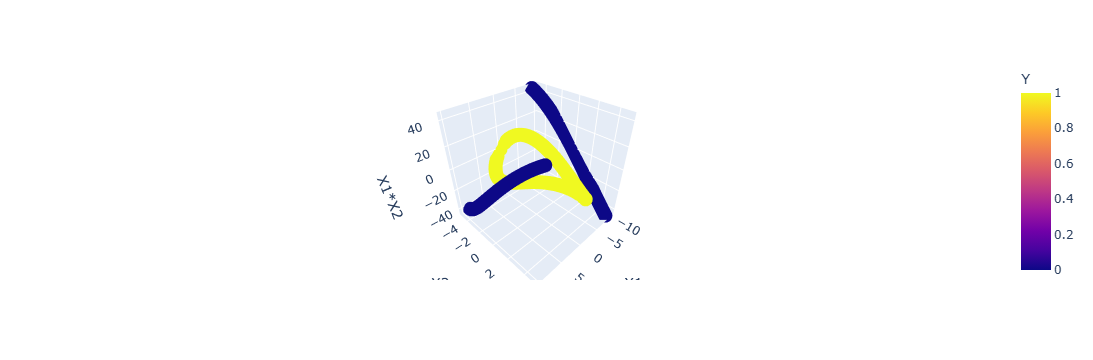

In [66]:
import plotly.express as px
fig=px.scatter_3d(df, x='X1',y='X2',z='X1*X2',color='Y')
fig.show()

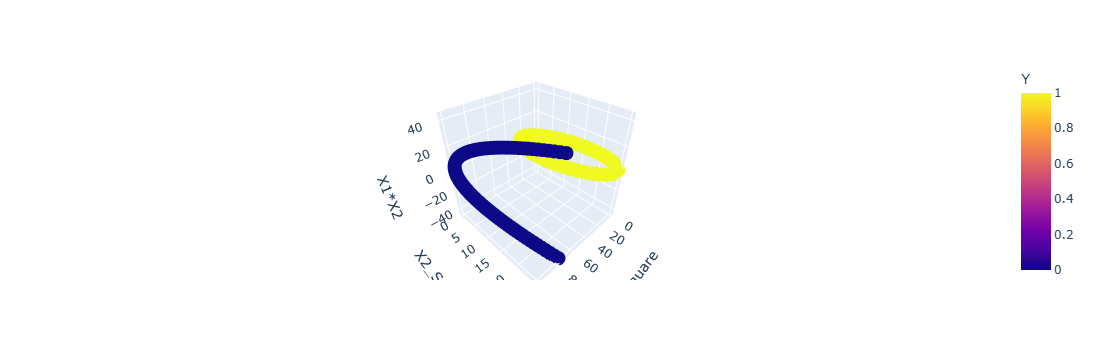

In [67]:
import plotly.express as px
fig=px.scatter_3d(df, x='X1_square',y='X2_Square',z='X1*X2',color='Y')
fig.show()

In [70]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
svc=SVC(kernel='linear')
svc.fit(X_train,y_train)
y_pred=svc.predict(X_test)
accuracy_score(y_test,y_pred)

1.0

In [76]:
poly=SVC(kernel='poly',degree=2)
poly.fit(X3_train,y3_train)
y_pred_poly=poly.predict(X3_test)
accuracy_score(y3_test,y_pred_poly)

1.0

In [75]:
rbf=SVC(kernel='rbf')
rbf.fit(X3_train,y3_train)
y_predict_rbf=rbf.predict(X3_test)
accuracy_score(y3_test,y_predict_rbf)

1.0